<a href="https://colab.research.google.com/github/saifbhatti004/AI-lab-task/blob/main/LAb_task_2_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv

# 1. Load the dataset
dataset_path = '/content/drive/MyDrive/AI LAB 2 DATASET/Crop_recommendation.csv'
data = []

with open(dataset_path, mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        processed_row = {
            'N': float(row['N']),
            'P': float(row['P']),
            'K': float(row['K']),
            'temperature': float(row['temperature']),
            'humidity': float(row['humidity']),
            'ph': float(row['ph']),
            'rainfall': float(row['rainfall']),
            'label': row['label']
        }
        data.append(processed_row)

# 2. Extract metadata
num_records = len(data)
features = list(data[0].keys())

print(f"Total Records: {num_records}")
print(f"Features: {features}\n")

# 3. Helper function for statistics
def calculate_feature_stats(dataset, feature_name):
    values = [row[feature_name] for row in dataset]
    min_val = min(values)
    max_val = max(values)
    avg_val = sum(values) / len(values)
    return min_val, max_val, avg_val

# 4. Print stats for N, Temperature, Rainfall
print("--- Environmental & Soil Statistics ---")
for feat in ['N', 'temperature', 'rainfall']:
    mi, ma, av = calculate_feature_stats(data, feat)
    print(f"{feat.capitalize()}: Min={mi:.2f}, Max={ma:.2f}, Avg={av:.2f}")

# Identify and print different crop categories
crop_categories = sorted(list(set([row['label'] for row in data])))
print(f"\nDifferent Crop Categories: {', '.join(crop_categories)}")

Total Records: 2200
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

--- Environmental & Soil Statistics ---
N: Min=0.00, Max=140.00, Avg=50.55
Temperature: Min=8.83, Max=43.68, Avg=25.62
Rainfall: Min=20.21, Max=298.56, Avg=103.46


### Average N, P, K values for each crop category

In [ ]:
# Calculate average N, P, K for each crop category
crop_categories = sorted(list(set([row['label'] for row in data]))) # Ensure crop_categories is defined
crop_nutrient_averages = {}

for crop_label in crop_categories:
    n_values = []
    p_values = []
    k_values = []

    for row in data:
        if row['label'] == crop_label:
            n_values.append(row['N'])
            p_values.append(row['P'])
            k_values.append(row['K'])

    avg_n = sum(n_values) / len(n_values) if n_values else 0
    avg_p = sum(p_values) / len(p_values) if p_values else 0
    avg_k = sum(k_values) / len(k_values) if k_values else 0

    crop_nutrient_averages[crop_label] = {
        'Avg_N': avg_n,
        'Avg_P': avg_p,
        'Avg_K': avg_k
    }

# Display the results
print("--- Average N, P, K values per Crop Category ---")
for crop, nutrients in crop_nutrient_averages.items():
    print(f"Crop: {crop}")
    print(f"  Average Nitrogen (N): {nutrients['Avg_N']:.2f}")
    print(f"  Average Phosphorus (P): {nutrients['Avg_P']:.2f}")
    print(f"  Average Potassium (K): {nutrients['Avg_K']:.2f}")
    print("------------------------------------------")

--- Average N, P, K values per Crop Category ---
Crop: apple
  Average Nitrogen (N): 20.80
  Average Phosphorus (P): 134.22
  Average Potassium (K): 199.89
------------------------------------------
Crop: banana
  Average Nitrogen (N): 100.23
  Average Phosphorus (P): 82.01
  Average Potassium (K): 50.05
------------------------------------------
Crop: blackgram
  Average Nitrogen (N): 40.02
  Average Phosphorus (P): 67.47
  Average Potassium (K): 19.24
------------------------------------------
Crop: chickpea
  Average Nitrogen (N): 40.09
  Average Phosphorus (P): 67.79
  Average Potassium (K): 79.92
------------------------------------------
Crop: coconut
  Average Nitrogen (N): 21.98
  Average Phosphorus (P): 16.93
  Average Potassium (K): 30.59
------------------------------------------
Crop: coffee
  Average Nitrogen (N): 101.20
  Average Phosphorus (P): 28.74
  Average Potassium (K): 29.94
------------------------------------------
Crop: cotton
  Average Nitrogen (N): 117.77
  Av

### Bar Plot of Average N, P, K values across all crops

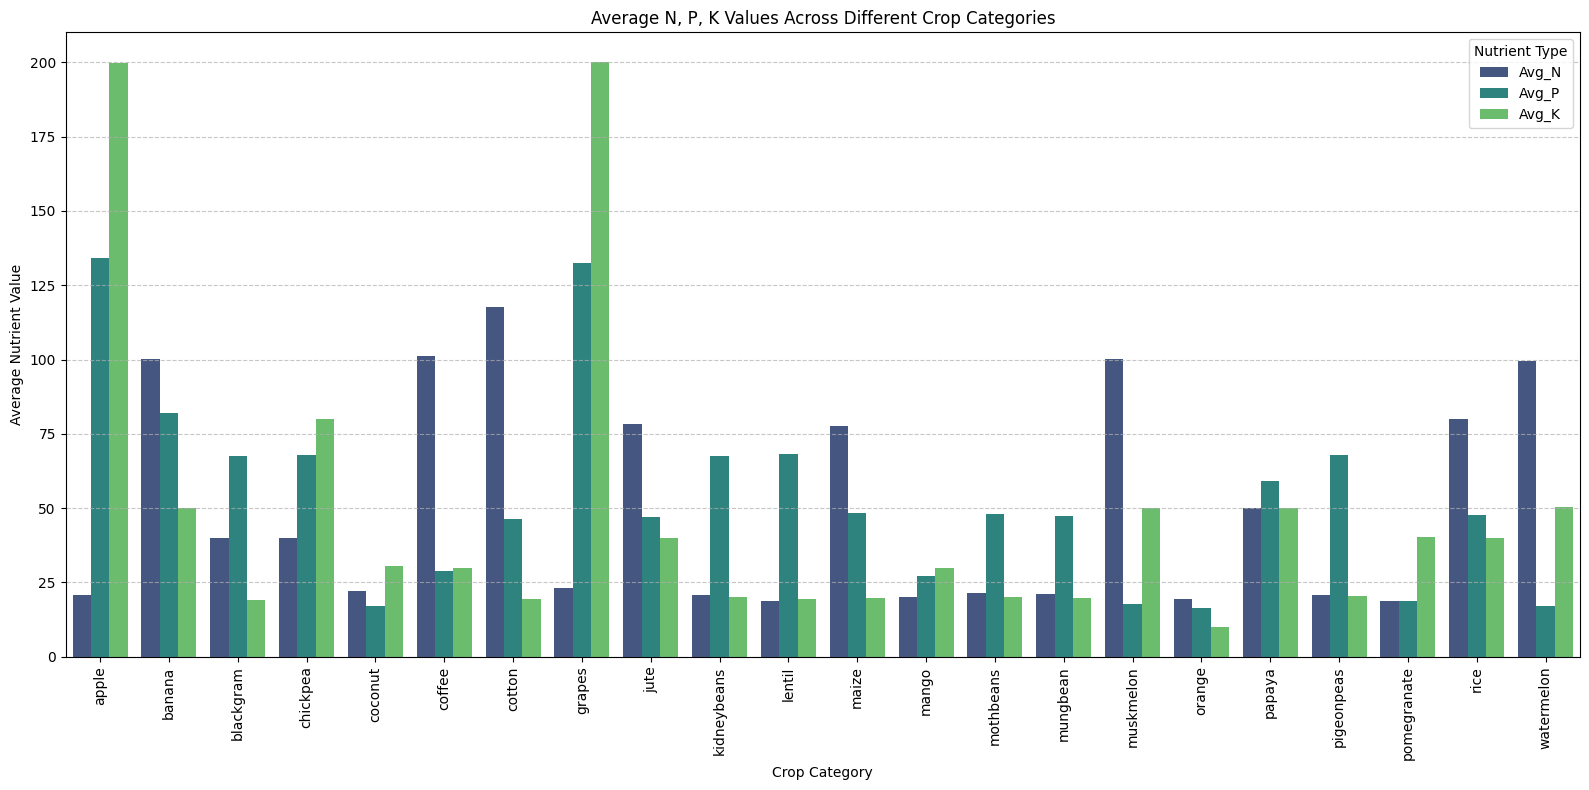

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the dictionary to a DataFrame for easier plotting
df_nutrient_averages = pd.DataFrame.from_dict(crop_nutrient_averages, orient='index')
df_nutrient_averages.index.name = 'Crop'

# Melt the DataFrame to prepare for grouped bar plot
df_melted = df_nutrient_averages.reset_index().melt(id_vars='Crop', var_name='Nutrient', value_name='Average Value')

# Create the bar plot
plt.figure(figsize=(16, 8))
sns.barplot(x='Crop', y='Average Value', hue='Nutrient', data=df_melted, palette='viridis')
plt.title('Average N, P, K Values Across Different Crop Categories')
plt.xlabel('Crop Category')
plt.ylabel('Average Nutrient Value')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.legend(title='Nutrient Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Relationship between Rainfall and pH for Top 5 Crops

In [ ]:
# 1. Get counts for each crop label
crop_counts = {}
for row in data:
    label = row['label']
    crop_counts[label] = crop_counts.get(label, 0) + 1

# 2. Sort crops by count in descending order to get top 5
sorted_crops = sorted(crop_counts.items(), key=lambda item: item[1], reverse=True)
top_5_crops = [crop[0] for crop in sorted_crops[:5]]

print(f"Top 5 Crops: {', '.join(top_5_crops)}\n")

# 3. Calculate average rainfall and pH for each of the top 5 crops
top_crop_env_averages = {}

for crop_label in top_5_crops:
    rainfall_values = []
    ph_values = []

    for row in data:
        if row['label'] == crop_label:
            rainfall_values.append(row['rainfall'])
            ph_values.append(row['ph'])

    avg_rainfall = sum(rainfall_values) / len(rainfall_values) if rainfall_values else 0
    avg_ph = sum(ph_values) / len(ph_values) if ph_values else 0

    top_crop_env_averages[crop_label] = {
        'Avg_Rainfall': avg_rainfall,
        'Avg_pH': avg_ph
    }

# 4. Display results and summarize
print("--- Average Rainfall and pH for Top 5 Crops ---")
for crop, env_data in top_crop_env_averages.items():
    print(f"Crop: {crop}")
    print(f"  Average Rainfall: {env_data['Avg_Rainfall']:.2f} mm")
    print(f"  Average pH: {env_data['Avg_pH']:.2f}")
    print("------------------------------------------")

# Summary of relationship
print("\nSummary of Relationship:")
print("By observing the average rainfall and pH values for these top 5 crops, we can identify general trends.")
print("For instance, some crops might thrive in high rainfall and slightly acidic pH, while others prefer lower rainfall and neutral pH.")
print("This information is crucial for optimizing irrigation and soil management strategies tailored to specific crop requirements.")

Top 5 Crops: rice, maize, chickpea, kidneybeans, pigeonpeas

--- Average Rainfall and pH for Top 5 Crops ---
Crop: rice
  Average Rainfall: 236.18 mm
  Average pH: 6.43
------------------------------------------
Crop: maize
  Average Rainfall: 84.77 mm
  Average pH: 6.25
------------------------------------------
Crop: chickpea
  Average Rainfall: 80.06 mm
  Average pH: 7.34
------------------------------------------
Crop: kidneybeans
  Average Rainfall: 105.92 mm
  Average pH: 5.75
------------------------------------------
Crop: pigeonpeas
  Average Rainfall: 149.46 mm
  Average pH: 5.79
------------------------------------------

Summary of Relationship:
By observing the average rainfall and pH values for these top 5 crops, we can identify general trends.
For instance, some crops might thrive in high rainfall and slightly acidic pH, while others prefer lower rainfall and neutral pH.
This information is crucial for optimizing irrigation and soil management strategies tailored to spec

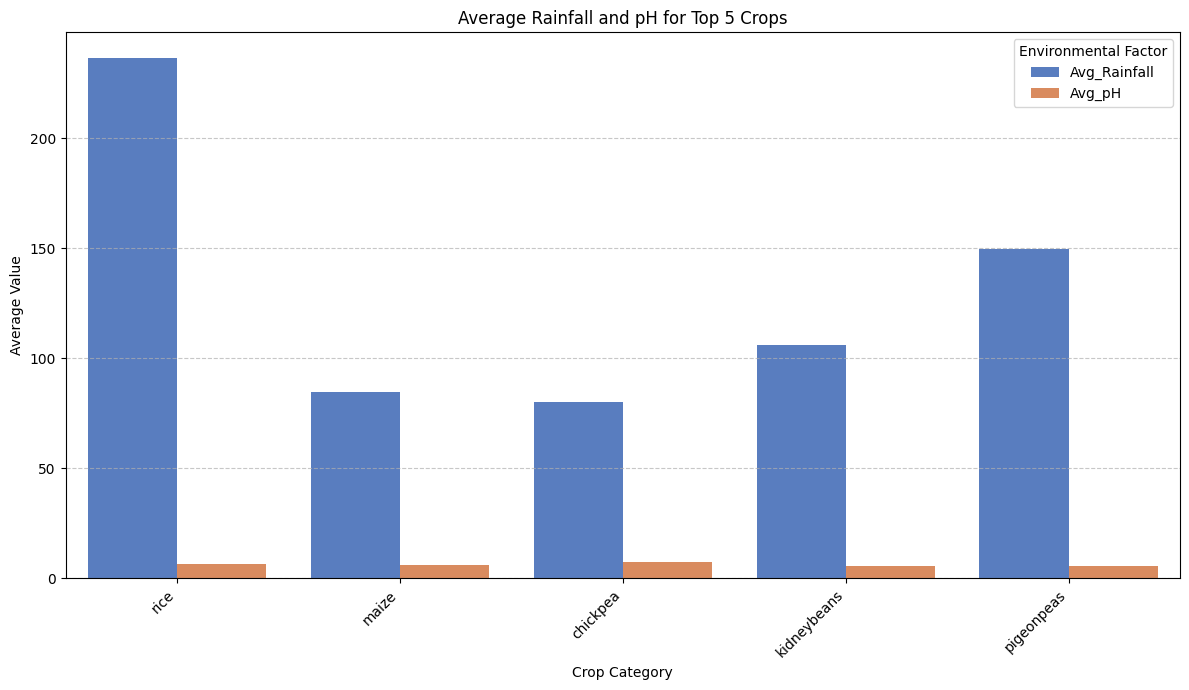

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the dictionary to a DataFrame for easier plotting
df_top_crop_env = pd.DataFrame.from_dict(top_crop_env_averages, orient='index')
df_top_crop_env.index.name = 'Crop'

# Melt the DataFrame to prepare for grouped bar plot
df_top_crop_env_melted = df_top_crop_env.reset_index().melt(id_vars='Crop', var_name='Environmental_Factor', value_name='Average Value')

# Create the grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Crop', y='Average Value', hue='Environmental_Factor', data=df_top_crop_env_melted, palette='muted')
plt.title('Average Rainfall and pH for Top 5 Crops')
plt.xlabel('Crop Category')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Environmental Factor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Calculate the correlation between rainfall and pH for all crops
correlation = df['rainfall'].corr(df['ph'])

print(f"Correlation between Rainfall and pH for all crops: {correlation:.2f}")

Correlation between Rainfall and pH for all crops: -0.11


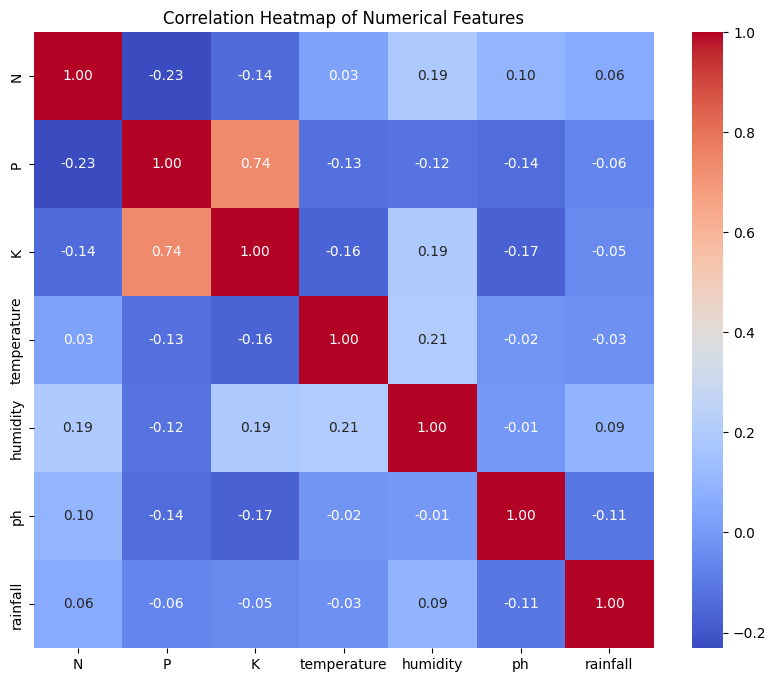

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

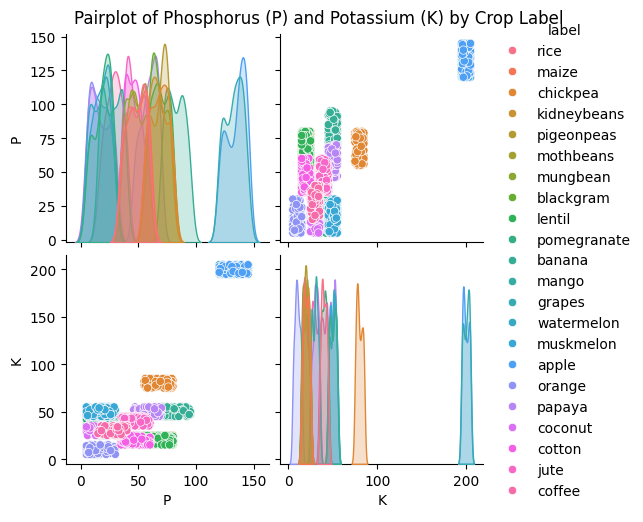

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot focusing on P, K, and hue by crop label
# Limiting to a subset of crops if needed for clarity due to many labels, but starting with all for now.
sns.pairplot(df[['P', 'K', 'label']], hue='label', diag_kind='kde')
plt.suptitle('Pairplot of Phosphorus (P) and Potassium (K) by Crop Label', y=1.02) # Adjust suptitle position
plt.show()

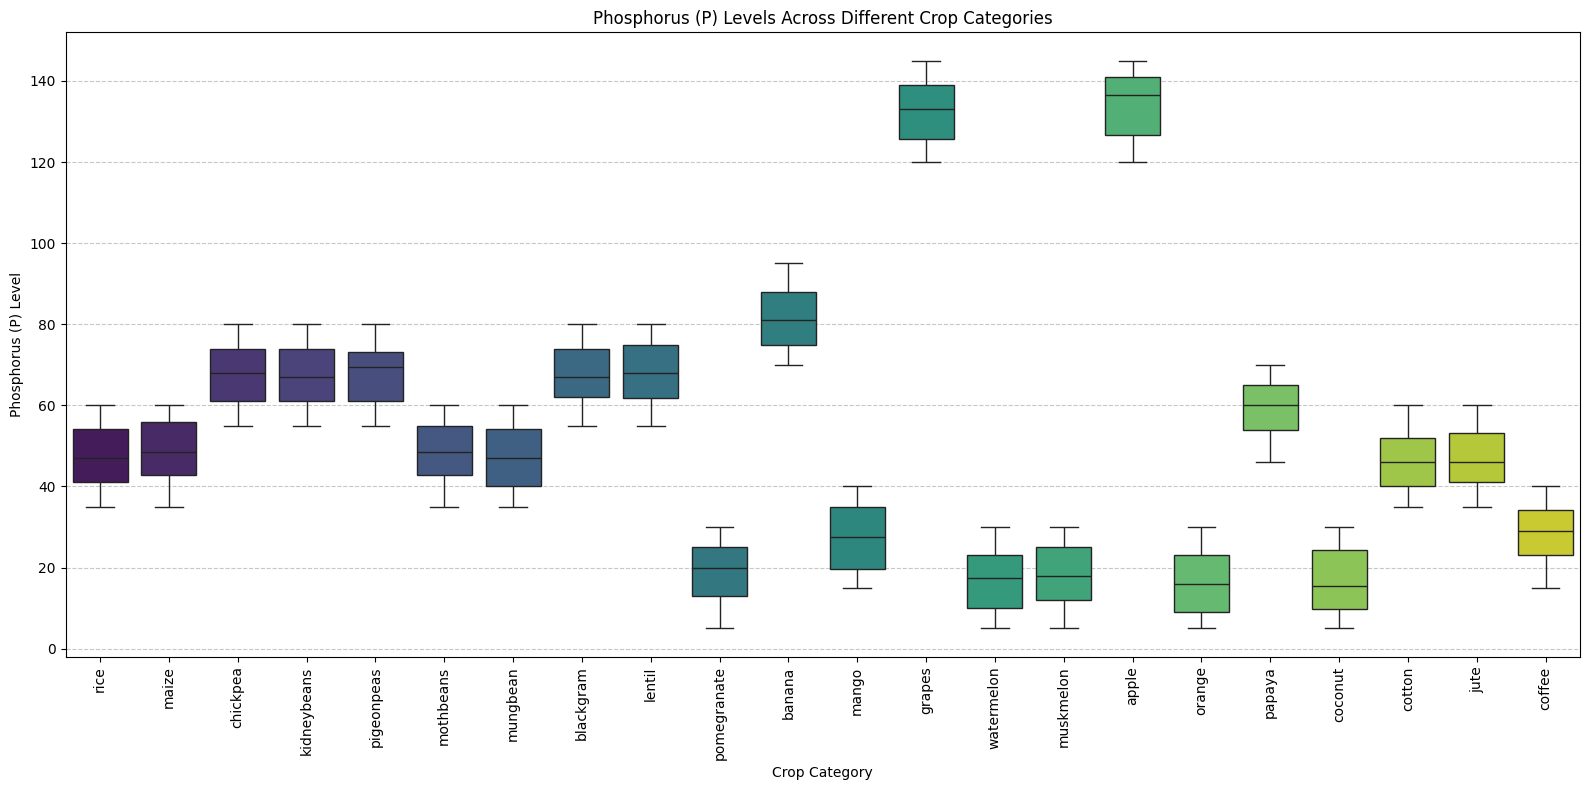

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='P', data=df, hue='label', palette='viridis', legend=False)
plt.title('Phosphorus (P) Levels Across Different Crop Categories')
plt.xlabel('Crop Category')
plt.ylabel('Phosphorus (P) Level')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

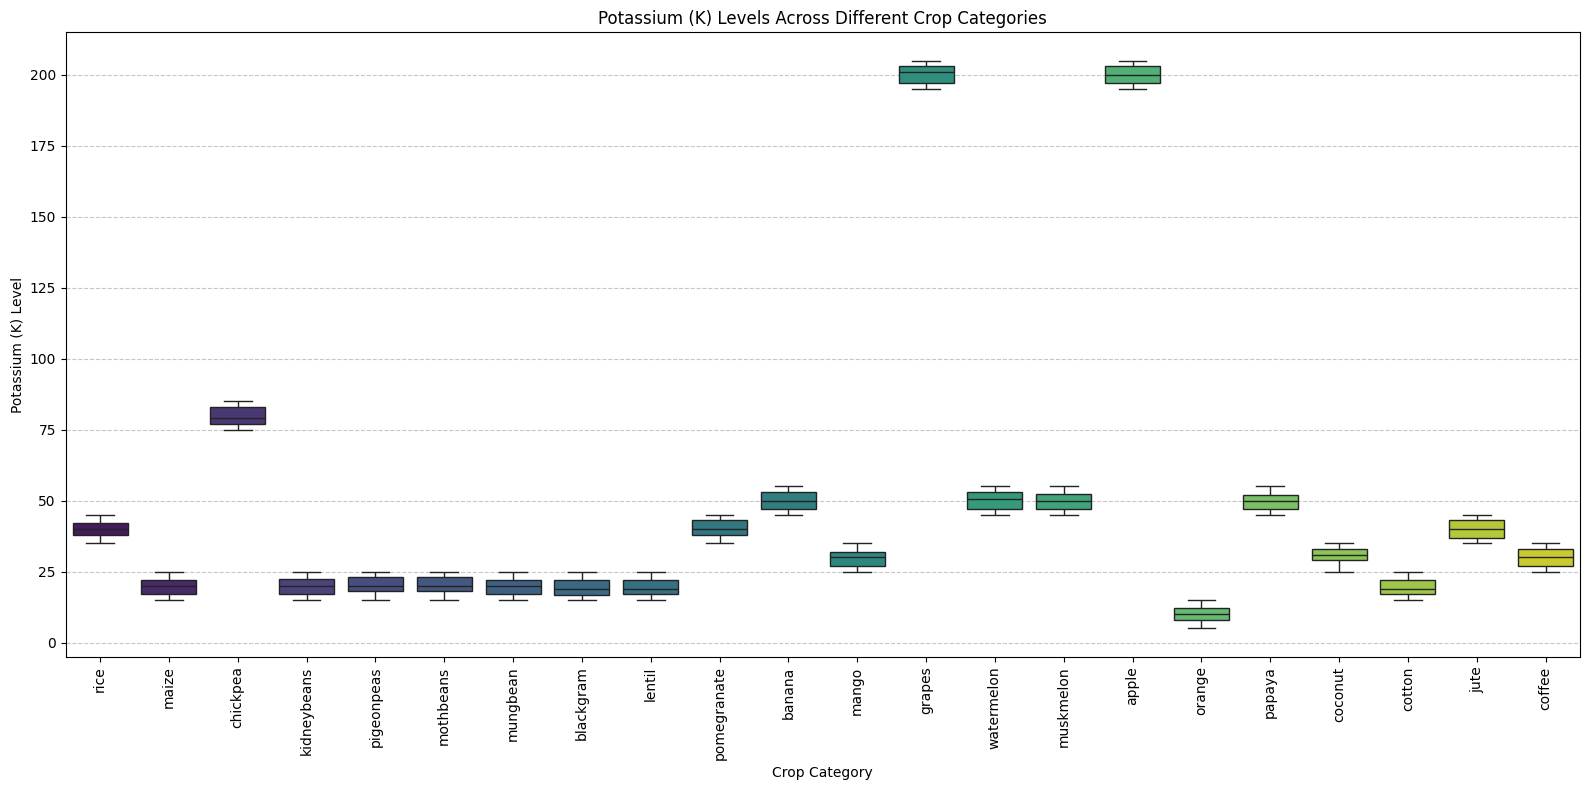

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='K', data=df, hue='label', palette='viridis', legend=False)
plt.title('Potassium (K) Levels Across Different Crop Categories')
plt.xlabel('Crop Category')
plt.ylabel('Potassium (K) Level')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

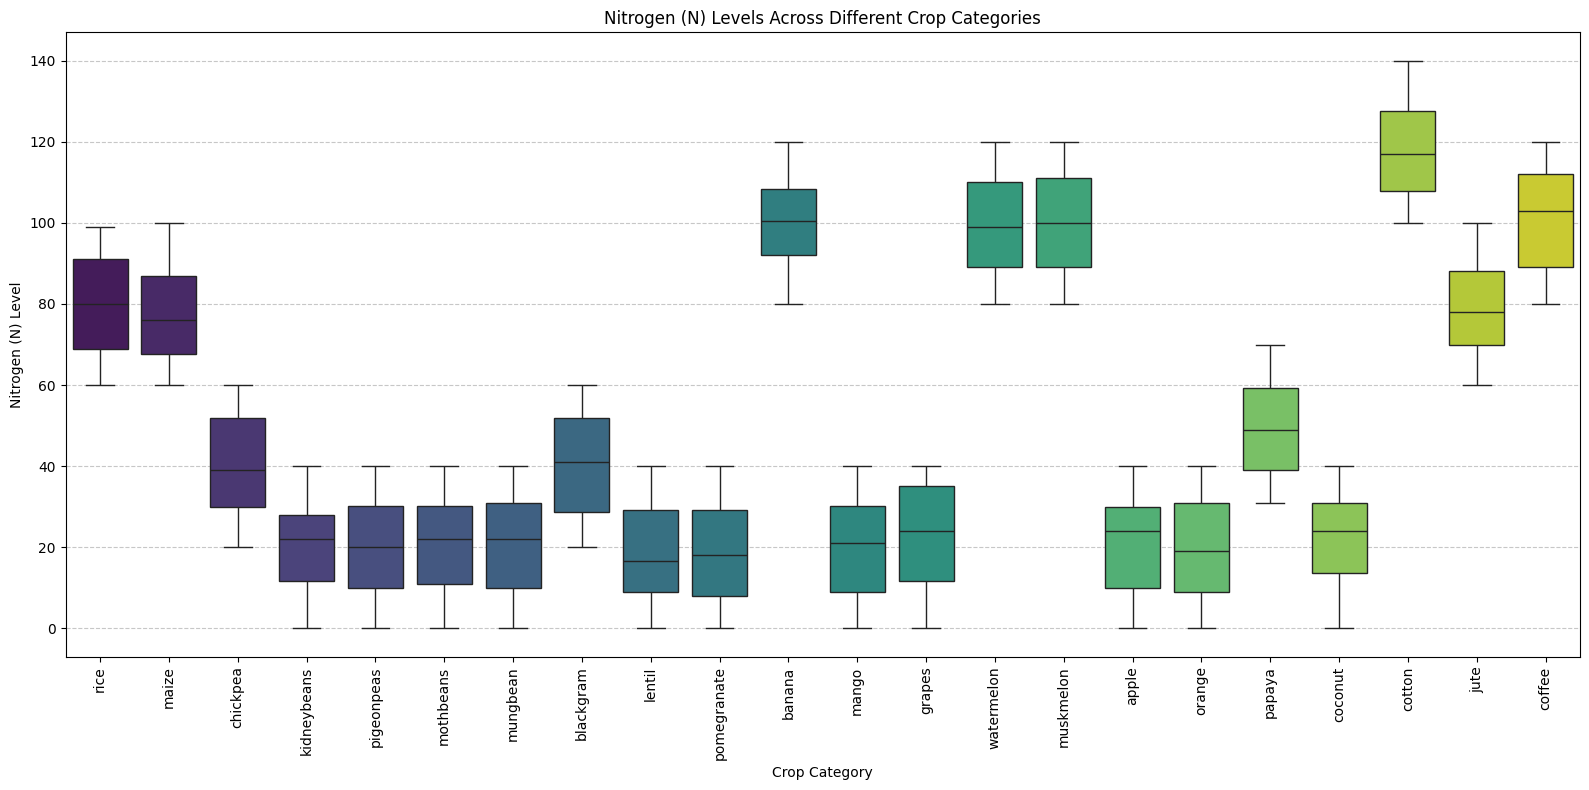

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='N', data=df, hue='label', palette='viridis', legend=False)
plt.title('Nitrogen (N) Levels Across Different Crop Categories')
plt.xlabel('Crop Category')
plt.ylabel('Nitrogen (N) Level')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

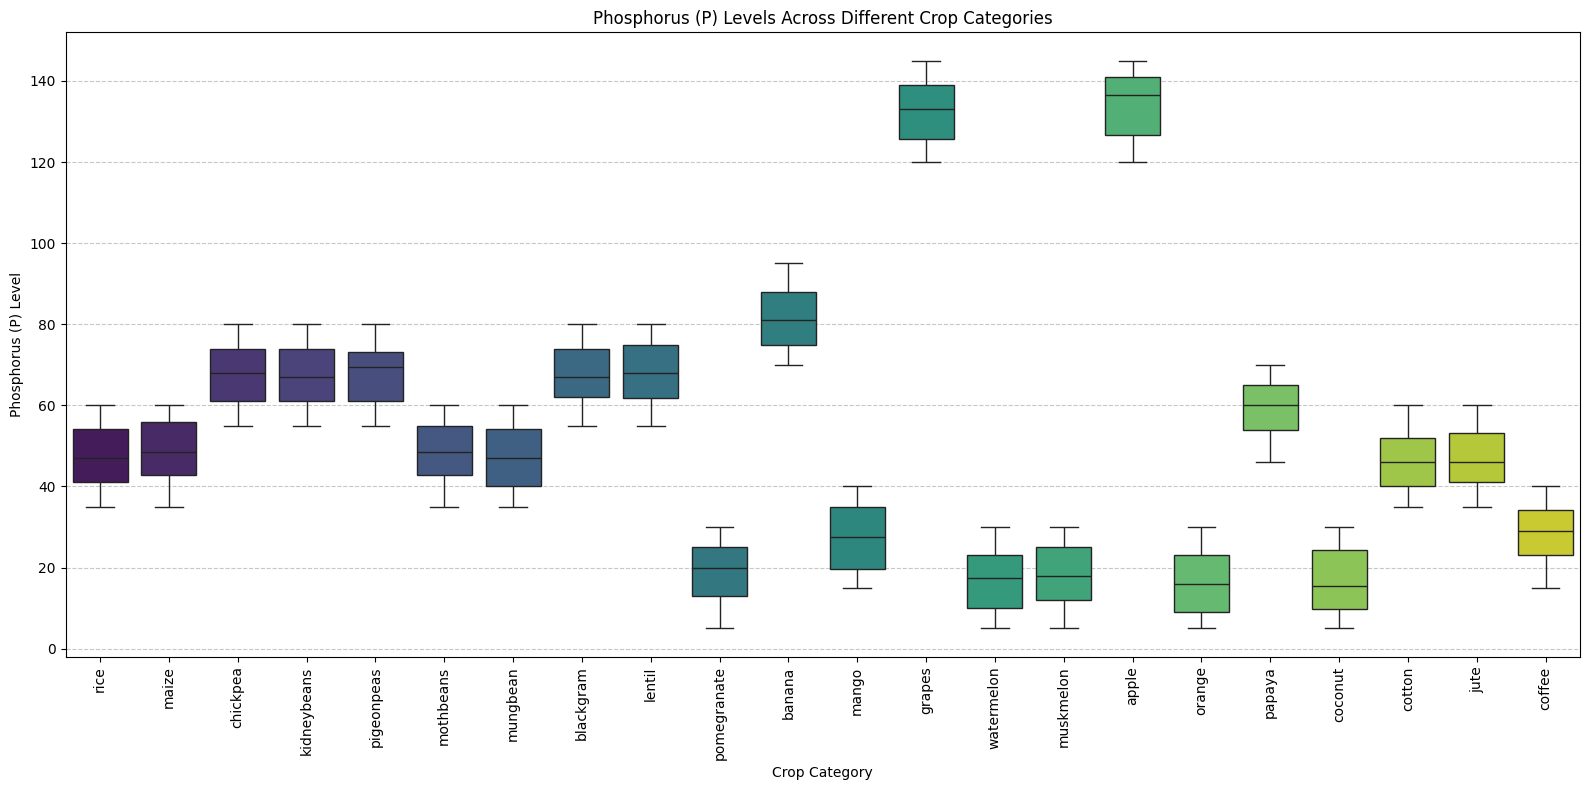

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='P', data=df, hue='label', palette='viridis', legend=False)
plt.title('Phosphorus (P) Levels Across Different Crop Categories')
plt.xlabel('Crop Category')
plt.ylabel('Phosphorus (P) Level')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

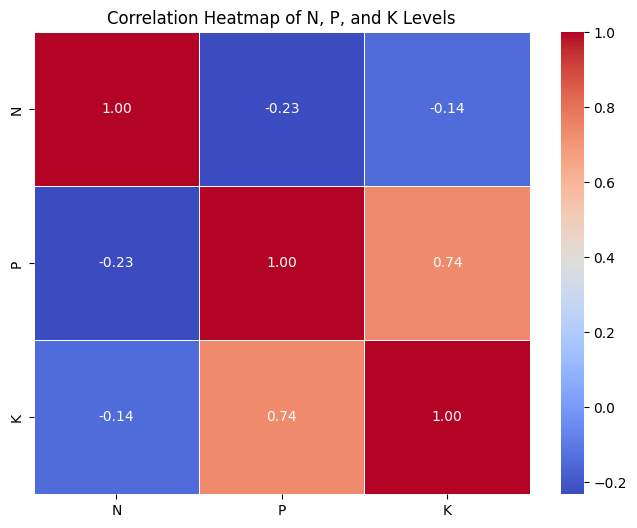

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only N, P, and K columns
npk_df = df[['N', 'P', 'K']]

# Calculate the correlation matrix for N, P, K
npk_correlation_matrix = npk_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(npk_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of N, P, and K Levels')
plt.show()

In [ ]:
import pandas as pd

# Convert the crop_nutrient_averages dictionary to a DataFrame for easier sorting
df_nutrient_averages_for_analysis = pd.DataFrame.from_dict(crop_nutrient_averages, orient='index')

# Identify crop with highest P
highest_p_crop = df_nutrient_averages_for_analysis['Avg_P'].idxmax()
highest_p_value = df_nutrient_averages_for_analysis['Avg_P'].max()

# Identify crop with highest K
highest_k_crop = df_nutrient_averages_for_analysis['Avg_K'].idxmax()
highest_k_value = df_nutrient_averages_for_analysis['Avg_K'].max()

print(f"Crop with the highest average Phosphorus (P) levels: {highest_p_crop} ({highest_p_value:.2f})")
print(f"Crop with the highest average Potassium (K) levels: {highest_k_crop} ({highest_k_value:.2f})")

Crop with the highest average Phosphorus (P) levels: apple (134.22)
Crop with the highest average Potassium (K) levels: grapes (200.11)


## Resources

In [ ]:
# Sort the DataFrame by 'Avg_P' in descending order and select the top 5
top_5_highest_p_crops = df_nutrient_averages.sort_values(by='Avg_P', ascending=False).head(5)

print("Top 5 Crops with the Highest Average Phosphorus (P) Levels:")
display(top_5_highest_p_crops[['Avg_P']])

Top 5 Crops with the Highest Average Phosphorus (P) Levels:


,Avg_P
Crop,
apple,134.22
grapes,132.53
banana,82.01
lentil,68.36
chickpea,67.79


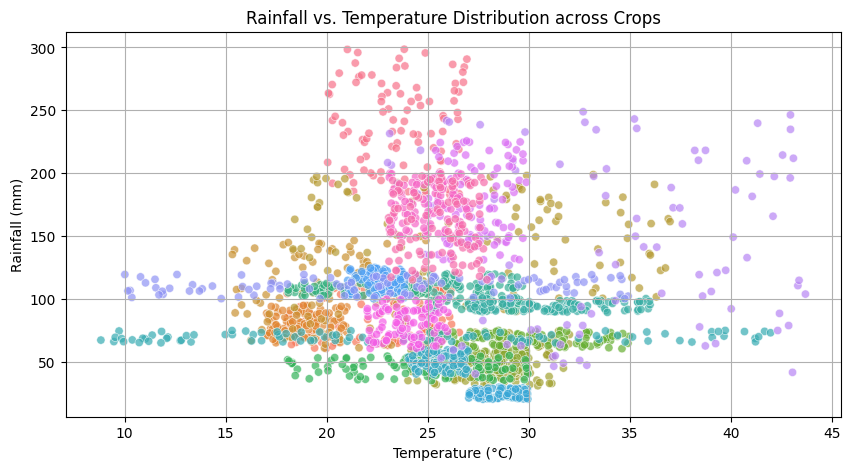

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load into Pandas for plotting
df = pd.read_csv('/content/drive/MyDrive/AI LAB 2 DATASET/Crop_recommendation.csv')

# Plot distribution of key parameters for top crops
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='temperature', y='rainfall', hue='label', legend=False, alpha=0.7)
plt.title('Rainfall vs. Temperature Distribution across Crops')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.grid(True)
plt.show()